<a href="https://colab.research.google.com/github/Balamurugan-T326/DEEP-LEARNING/blob/main/EXPERIMENT-3/PART-A%2CB%2CC%2CD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART A

In [2]:
print("24BAD016 BALAMURUGAN T")
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models

24BAD016 BALAMURUGAN T


LOAD THE CIFAR-10 DATASET

In [4]:
  (x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


DEFINE CLASS NAMES

In [5]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "-", name)

Classes:
0 - airplane
1 - automobile
2 - bird
3 - cat
4 - deer
5 - dog
6 - frog
7 - horse
8 - ship
9 - truck


DISPLAY SAMPLE IMAGES


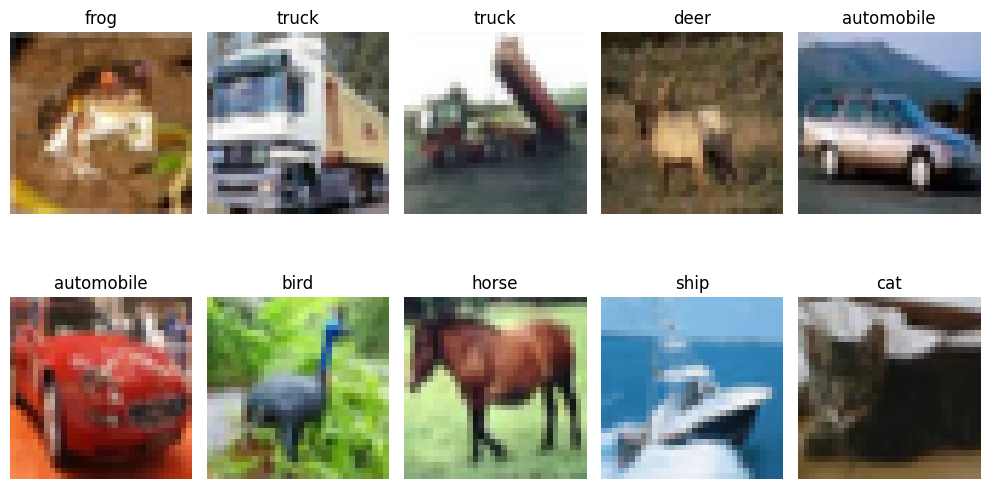

In [7]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

IMAGE PREPROCESSING

In [8]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


SPLIT TRAINING AND VALIDATION DATA

In [9]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train_new = x_train[:-5000]
y_train_new = y_train[:-5000]

print("Training data:", x_train_new.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

Training data: (45000, 32, 32, 3)
Validation data: (5000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


PART B – CNN MODEL IMPLEMENTATION

In [10]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


VIEW MODEL ARCHITECTURE

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

COMPILE THE MODEL

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


PART C – MODEL TRAINING

In [13]:
history = model.fit(
    x_train_new,
    y_train_new,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 89ms/step - accuracy: 0.4148 - loss: 1.6031 - val_accuracy: 0.5164 - val_loss: 1.3486
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5524 - loss: 1.2586 - val_accuracy: 0.5748 - val_loss: 1.2120
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 87ms/step - accuracy: 0.6106 - loss: 1.1046 - val_accuracy: 0.6132 - val_loss: 1.0987
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6542 - loss: 0.9907 - val_accuracy: 0.6384 - val_loss: 1.0287
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.6768 - loss: 0.9249 - val_accuracy: 0.6836 - val_loss: 0.9193
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 85ms/step - accuracy: 0.6990 - loss: 0.8587 - val_accuracy: 0.6858 - val_loss: 0.8975
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 88ms/step - accuracy: 0.7171 - loss: 0.8078 - val_accuracy: 0.7058 - val_loss: 0.8598
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 87ms/step - accuracy: 0.7340 - loss: 0.7648 - 

RECORD TRAINING AND VALIDATION ACCURACY

In [14]:
print("Final Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

print("Final Training Loss:",
      history.history['loss'][-1])

print("Final Validation Loss:",
      history.history['val_loss'][-1])

Final Training Accuracy: 0.7587555646896362
Final Validation Accuracy: 0.7210000157356262
Final Training Loss: 0.6870565414428711
Final Validation Loss: 0.8367583155632019


PLOT ACCURACY VS EPOCH

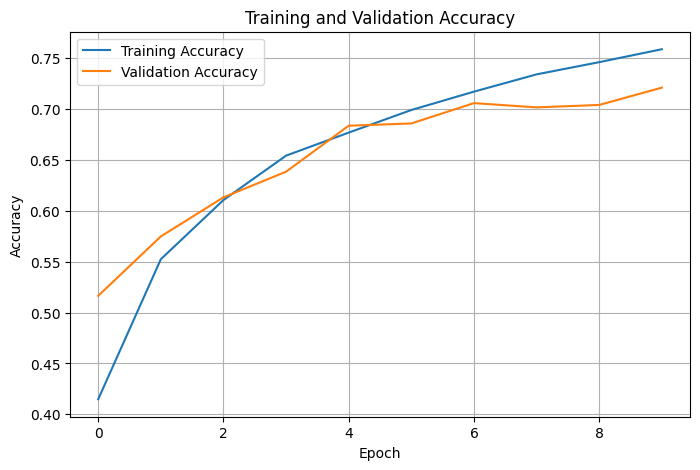

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

PLOT LOSS VS EPOCH

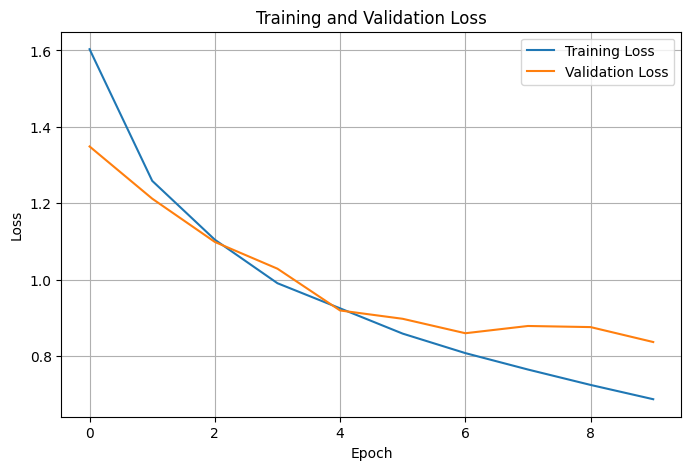

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

TEST THE MODEL

In [17]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7094 - loss: 0.8546
Test Loss: 0.85455721616745
Test Accuracy: 0.7093999981880188


PART D – PERFORMANCE ANALYSIS

In [18]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Predictions generated successfully.


DISPLAY SAMPLE PREDICTIONS

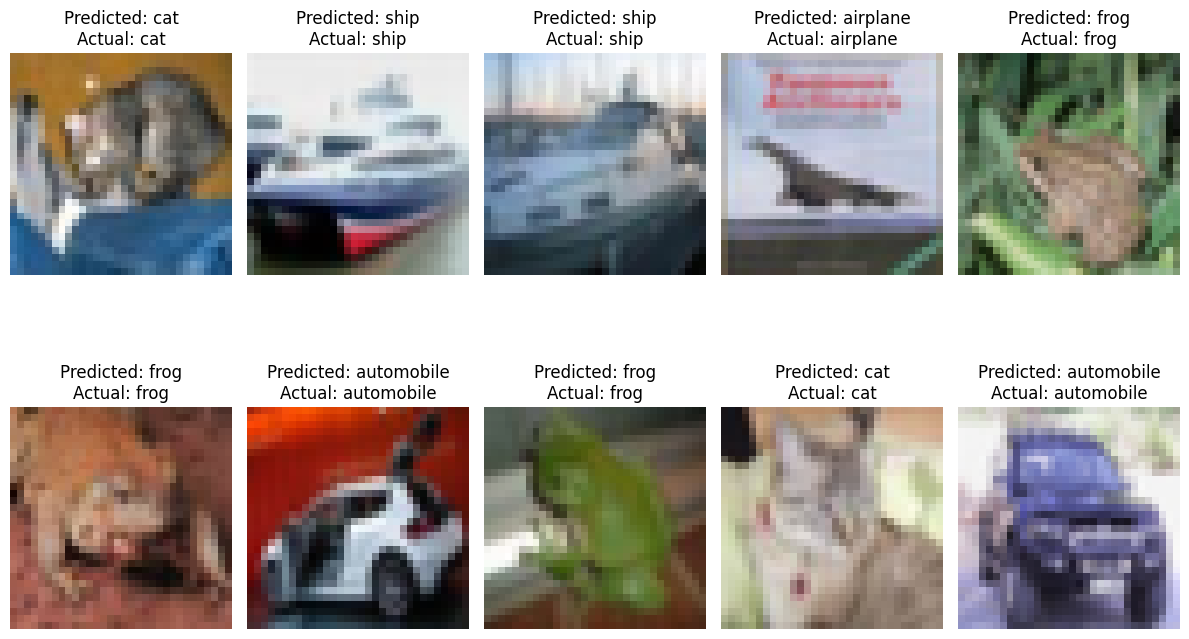

In [19]:
plt.figure(figsize=(12, 8))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i])

    predicted = class_names[predicted_labels[i]]
    actual = class_names[y_test[i][0]]

    plt.title(
        f"Predicted: {predicted}\nActual: {actual}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

CONFUSION MATRIX

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [22]:
cm = confusion_matrix(
    y_test.flatten(),
    predicted_labels
)

print(cm)

[[777  19  26  21  29   6  11  11  57  43]
 [ 27 789   8   7   9   5  15   6  17 117]
 [ 82   7 504  81 128  80  68  22  14  14]
 [ 23   6  49 568  76 148  68  23  10  29]
 [ 22   3  35  85 724  30  48  41   7   5]
 [ 13   0  35 205  58 608  30  34   7  10]
 [ 10   3  25  73  37  14 820   6   8   4]
 [ 23   4  22  70  91  73  11 687   3  16]
 [ 75  36   7  15  13   8   7   4 786  49]
 [ 40  49   3  20  11   7  10   8  21 831]]


Visualize Confusion Matrix

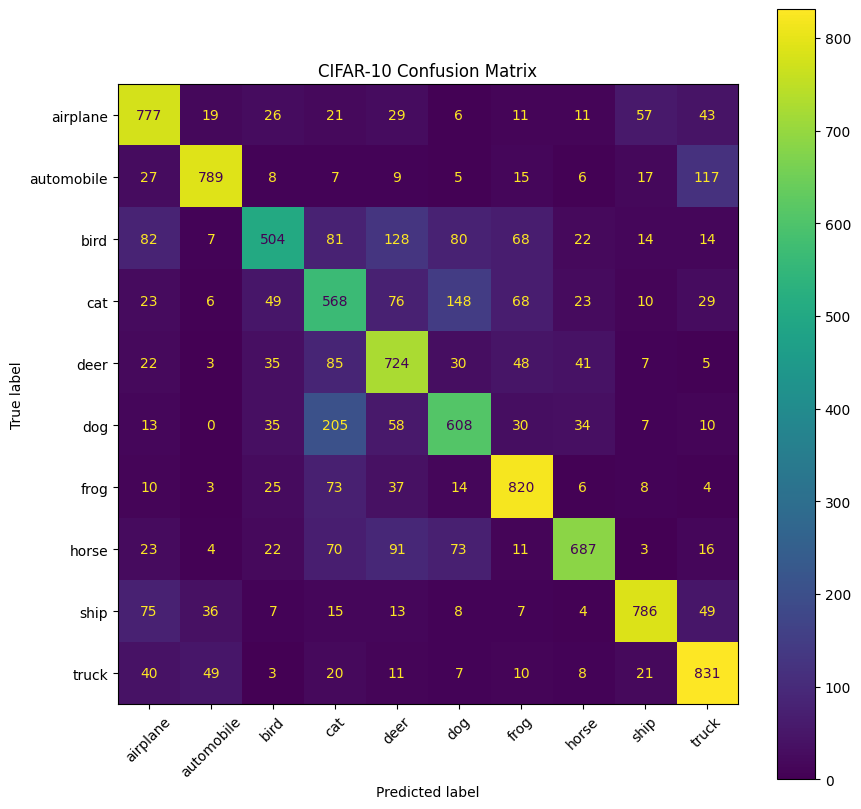

In [23]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("CIFAR-10 Confusion Matrix")
plt.show()

FIND MISCLASSIFIED IMAGES

In [24]:
misclassified = np.where(
    predicted_labels != y_test.flatten()
)[0]

print(
    "Number of misclassified images:",
    len(misclassified)
)

Number of misclassified images: 2906


DISPLAY MISCLASSIFIED IMAGES

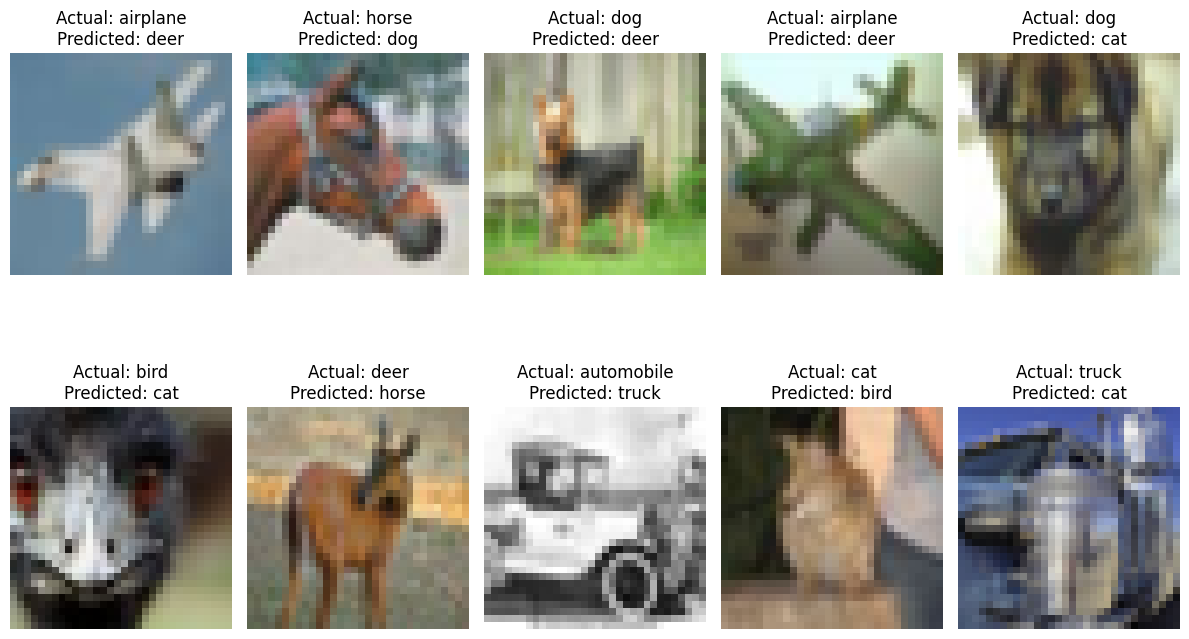

In [25]:
plt.figure(figsize=(12, 8))

for i in range(10):

    index = misclassified[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[index])

    actual = class_names[y_test[index][0]]
    predicted = class_names[predicted_labels[index]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()